In [1]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

In [2]:
# SSL / proxy setup for corporate network + quiet health check
import os
from pathlib import Path
import requests
from dotenv import load_dotenv

load_dotenv()

candidate_paths = [
    os.getenv("CORP_CA_BUNDLE"),
    os.getenv("REQUESTS_CA_BUNDLE"),
    os.getenv("SSL_CERT_FILE"),
    "/etc/ssl/certs/ca-certificates.crt",
    "/usr/lib/ssl/cert.pem",
]

selected_bundle = next(
    (path for path in candidate_paths if path and Path(path).exists()),
    None,
 )

if selected_bundle:
    os.environ["REQUESTS_CA_BUNDLE"] = selected_bundle
    os.environ["SSL_CERT_FILE"] = selected_bundle

diagnostics = []

if not selected_bundle:
    diagnostics.append(
        "No CA bundle found from known paths. Set CORP_CA_BUNDLE in .env."
    )

if not os.getenv("http_proxy") and not os.getenv("https_proxy"):
    diagnostics.append(
        "No proxy env detected. If required in your network, set http_proxy/https_proxy in .env."
    )

try:
    requests.get("https://api.tavily.com", timeout=10)
except requests.exceptions.SSLError as exc:
    diagnostics.append(
        "TLS handshake failed. Export corporate root cert to PEM and set CORP_CA_BUNDLE in .env."
    )
    diagnostics.append(f"SSL error: {exc}")
except Exception as exc:
    diagnostics.append(
        f"Connectivity check failed with {type(exc).__name__}: {exc}"
    )

if diagnostics:
    print("[SSL Check] Action needed:")
    for line in diagnostics:
        print(f"- {line}")

# Research Agent 

*The goal of research is to gather the context requested by the research brief.*

Here is our overall research flow:

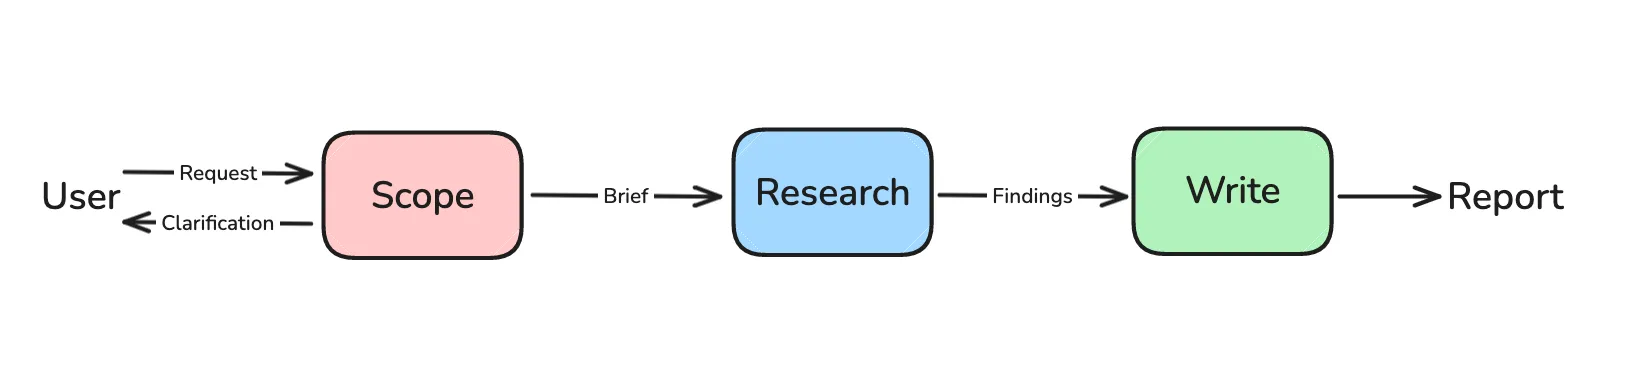

Research is an open‑ended task. The best strategy to answer a user request can't be easily known in advance. 

Requests can require different research strategies and varying levels of search depth. Consider this request:

> *"Compare these two products"*

Comparisons typically benefit from search on each product, followed by a synthesis step to compare them. Now, consider this one:

> *"Give me the top candidates for my job posting"*

Listing and ranking requests typically require open-ended search, followed by a synthesis and ranking.
 
[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) are well suited to research because they can flexibly apply different strategies, using intermediate results to guide their exploration.

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

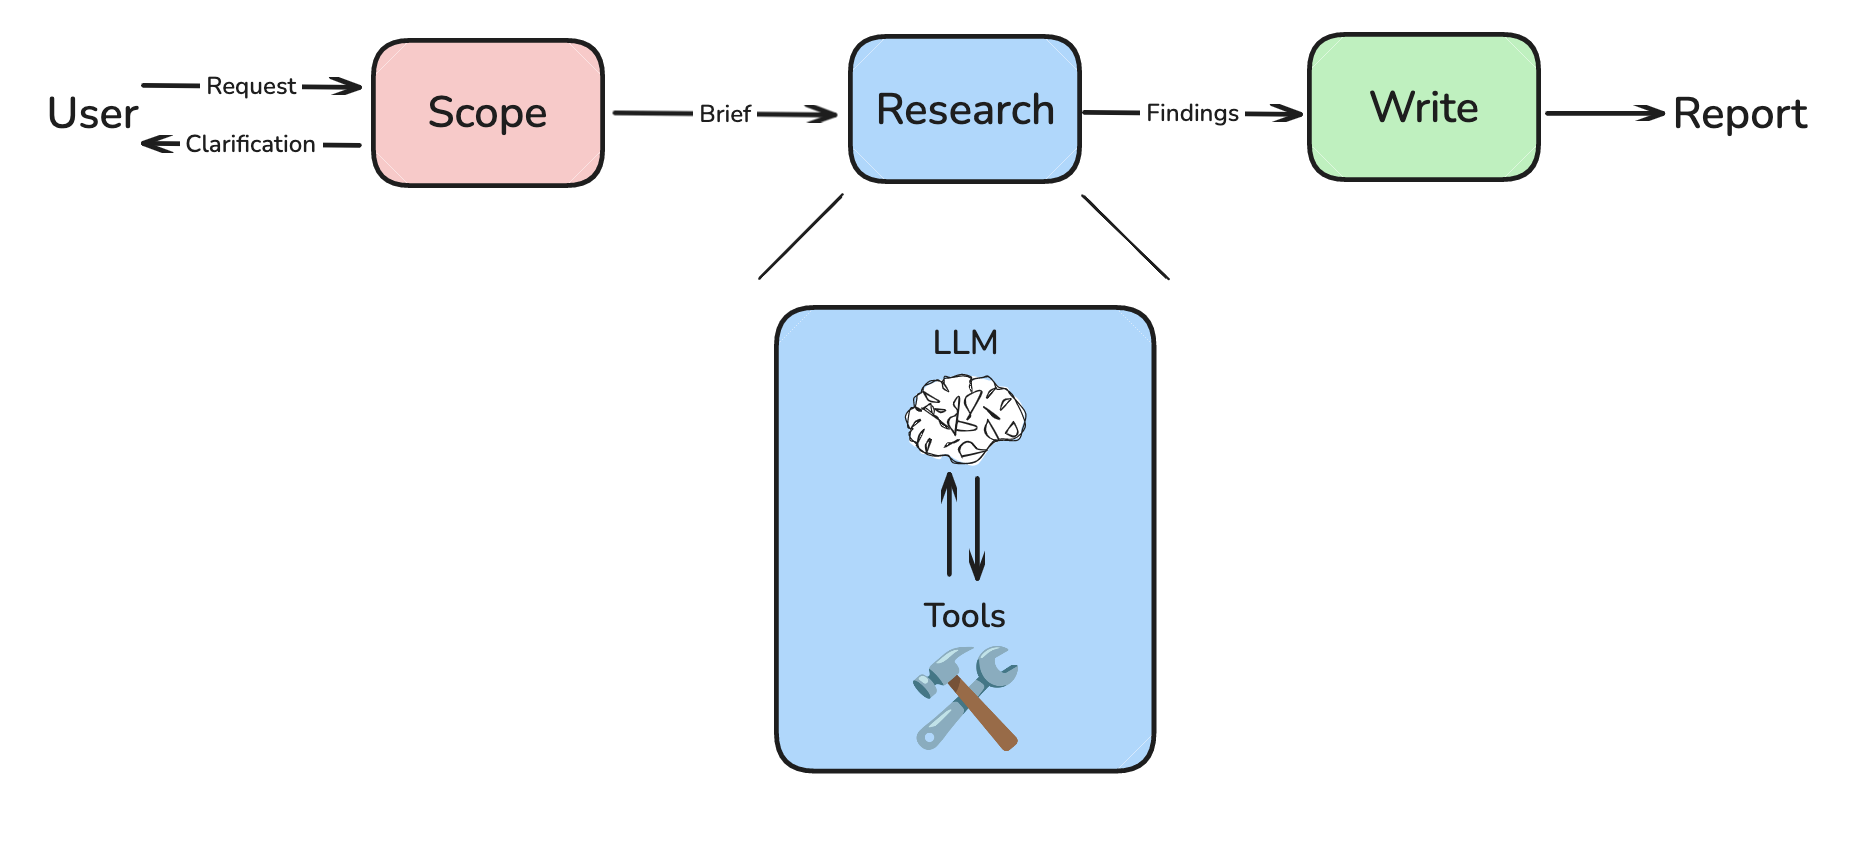

### Prompt

First, we'll define a prompt that instructs our agent to use available search tools. 

To prevent excessive tool calls and maintain research focus, we use [a few prompting techniques for agents](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA):

#### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Start with broader searches** - Use broad, comprehensive queries first
- **After each search, pause and assess** - Do I have enough to answer? What's still missing?
- **Execute narrower searches as you gather information** - Fill in the gaps.

#### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Stop when you can answer confidently** - Don't keep searching for perfection.
- **Give it budgets** - Use 2-3 search tool calls for simple queries. Use up to 5 for complex queries.
- **Limit** - Always stop after 5 search tool calls if you cannot find the right source(s).

#### 3. Show your thinking
After each search tool calling, use [`think_tool` to analyze the results](https://www.anthropic.com/engineering/claude-think-tool):
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

#### Results
These techniques transform problematic research behavior like:
```
"best coffee shops SF" → "Saint Frank Coffee details" → "Sightglass Coffee details" → "Ritual Coffee details" → etc. (20+ searches)
```

Into efficient patterns like:
```
"best coffee shops SF" → ThinkTool(analyze results) → "SF specialty coffee quality ratings" → ThinkTool(assess completeness) → provide answer (3-5 searches total)
```

The key insight: **Think like a human researcher with limited time** - this prevents the "spin-out problem" where agents continue searching indefinitely.

In [3]:
from utils import show_prompt
from deep_research_from_scratch.prompts import research_agent_prompt
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Image Collection>                                                                                             │
│  Search results may include relevant images (charts, diagrams, screenshots, data visualizations).               │
│  Note any images that are directly relevant to the research topic in your thinking — these will be              │
│  preserved and embedded in the final report. You do not need to take any special action to collect              │
│  images; they are captured automatically from search results.                                                   │
│  </Image Collection>                                                                                            │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                      

### State and Schemas

We'll create the agent state object.


In [4]:
%%writefile ../src/deep_research_from_scratch/state_research.py

"""State Definitions and Pydantic Schemas for Research Agent.

This module defines the state objects and structured schemas used for
the research agent workflow, including researcher state management and output schemas.
"""

import operator

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from typing_extensions import Annotated, List, Sequence, TypedDict

# ===== IMAGE METADATA SCHEMA =====

class ImageResult(BaseModel):
    """Schema for image metadata collected during research."""

    url: str = Field(description="URL of the image")
    title: str = Field(
        description="Title or alt text of the image", default=""
    )
    source_page: str = Field(
        description="URL of the page where the image was found", default=""
    )
    description: str = Field(
        description="Brief description of the image content", default=""
    )
    local_path: str | None = Field(
        description="Local file path after download", default=None
    )
    # Page-discovery context (populated by batch_discover_images)
    discovery_method: str = Field(
        description="How the image was found: 'tavily' or 'httpx'", default="tavily"
    )
    page_title: str = Field(
        description="<title> of the page where the image was found", default=""
    )
    alt_text: str = Field(
        description="alt attribute of the <img> element", default=""
    )
    figcaption: str = Field(
        description="Caption from a parent <figure> element", default=""
    )

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """State for the research agent containing message history and research metadata.

    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    images: Annotated[List[ImageResult], operator.add]

class ResearcherOutputState(TypedDict):
    """Output state for the research agent containing final research results.

    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    images: Annotated[List[ImageResult], operator.add]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decisions during scoping phase."""
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")


Overwriting ../src/deep_research_from_scratch/state_research.py


Now, we'll define our research tool.  

#### Tavily SDK Integration

We'll use the [Tavily SDK](https://docs.tavily.com/sdk/python/reference) to perform web searches.
 
Tavily is a search engine optimized for AI applications with a generous free tier, providing:
- Real-time web search results
- Content extraction and summarization
- Domain filtering and result ranking
- Async support for performance

#### Alternative Web Content Sources

While we use Tavily's search API in this tutorial, there are several other excellent options for web content extraction:

- **[Tavily Extract](https://docs.tavily.com/documentation/api-reference/endpoint/extract)**: Tavily's dedicated content extraction endpoint that can extract and clean content from specific URLs without performing searches
- **[Jina Reader](https://jina.ai/reader/)**: A powerful web content extraction service that converts web pages to clean, LLM-friendly text by simply prepending `https://r.jina.ai/` to any URL
- **[Firecrawl](https://www.firecrawl.dev/)**: A comprehensive web scraping platform that converts websites into clean markdown or structured data, with advanced features like JavaScript rendering and sitemap crawling

Each tool has different strengths: Tavily excels at search-first workflows, Jina Reader offers the simplest URL-to-text conversion, and Firecrawl provides the most comprehensive web scraping capabilities for complex sites.

####  LangChain Tools

We'll convert our Tavily search function into a [LangChain tool](https://python.langchain.com/docs/concepts/tools/) using the `@tool` decorator. This enables:
- Automatic schema generation for the LLM
- Integration with LangChain's agent framework
- Standardized tool calling interface
- Type validation and documentation

Note that some of the arguments are noted as [InjectedToolArg](https://python.langchain.com/api_reference/core/tools/langchain_core.tools.base.InjectedToolArg.html). These are not included in the tool schema sent to the LLM, and instead are injected during execution. This gives us the flexibility to inject values at runtime, but does not burden the language model with the responsibility of managing these arguments.

In [2]:
%%writefile ../src/deep_research_from_scratch/utils.py

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

import contextvars
import json
import logging
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime
from pathlib import Path
from urllib.parse import urljoin, urlparse

import httpx
import requests
import urllib3
from bs4 import BeautifulSoup
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage
from langchain_core.tools import InjectedToolArg, tool
from tavily import TavilyClient
from typing_extensions import Annotated, List, Literal

from deep_research_from_scratch.Helper import GenAIToken
from deep_research_from_scratch.prompts import summarize_webpage_prompt
from deep_research_from_scratch.state_research import ImageResult, Summary

load_dotenv()
logger = logging.getLogger(__name__)

# ===== SSL CONFIGURATION =====
# Set DISABLE_SSL_VERIFY=true in .env to skip certificate verification when
# operating behind a corporate proxy with self-signed certificates.
_DISABLE_SSL = os.getenv("DISABLE_SSL_VERIFY", "").lower() in ("1", "true", "yes")
if _DISABLE_SSL:
    import ssl

    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    # Patch Python's ssl module so stdlib HTTPS clients (urllib.request,
    # http.client) also skip verification.
    ssl._create_default_https_context = ssl._create_unverified_context  # noqa: SLF001

    # Remove env vars that would re-enable cert verification inside
    # requests.Session.merge_environment_settings.
    for _env_var in ("REQUESTS_CA_BUNDLE", "CURL_CA_BUNDLE"):
        os.environ.pop(_env_var, None)

    # Patch requests.Session.merge_environment_settings to force verify=False.
    # Why this level:
    #   requests.post() → Session() → session.request() →
    #   merge_environment_settings() → session.send(verify=...)
    # Thread-safe: each call operates on its own settings dict —
    #   no shared mutable state, so concurrent asyncio.gather() sub-agents
    #   cannot race each other (unlike the old requests.post swap approach).
    # Autoreload-safe: requests is in site-packages, so %autoreload 2
    #   does not reload it and the class-level patch persists.
    if not getattr(requests.Session, "_ssl_patched", False):
        _orig_merge = requests.Session.merge_environment_settings

        def _merge_no_verify(  # noqa: ANN001
            self, url, proxies=None, stream=False, verify=True, cert=None,
            *, _orig=_orig_merge,
        ):
            if proxies is None:
                proxies = {}
            settings = _orig(self, url, proxies, stream, verify, cert)
            settings["verify"] = False
            return settings

        requests.Session.merge_environment_settings = _merge_no_verify
        requests.Session._ssl_patched = True  # type: ignore[attr-defined]

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

_DEFAULT_SUMMARIZATION_MODEL = "azure_openai:gpt-4.1"
_runtime_config: contextvars.ContextVar[dict] = contextvars.ContextVar(
    "runtime_config",
    default={},
)


def set_runtime_config(configurable: dict | None) -> None:
    """Store runtime model overrides for tool-side model resolution."""
    _runtime_config.set(dict(configurable or {}))


def get_runtime_config() -> dict:
    """Return the current runtime model overrides for tool-side helpers."""
    return dict(_runtime_config.get())


_last_search_images: contextvars.ContextVar[list[ImageResult]] = (
    contextvars.ContextVar("last_search_images", default=[])
)


def get_last_search_images() -> list[ImageResult]:
    """Retrieve images extracted from the most recent search call.

    Used by tool_node to pass image metadata into the agent state
    without changing the tool's string return interface.
    """
    return list(_last_search_images.get())


_inspected_page_urls: contextvars.ContextVar[set[str]] = contextvars.ContextVar(
    "inspected_page_urls", default=set()
)


def reset_page_discovery_cache() -> None:
    """Reset the cross-call URL skip set.

    Call in tests for isolation between test cases.
    """
    _inspected_page_urls.set(set())


def normalize_model_id(model_id: str) -> str:
    """Normalize Azure model identifiers to use the expected deployment casing."""
    provider, separator, deployment = model_id.partition(":")
    if not separator:
        return model_id
    return f"{provider}{separator}{deployment.upper()}"


def _build_summarization_model(
    model_id: str | None = None,
    temperature: float = 0.0,
):
    """Build the summarization model with a fresh GenAI token.

    Fallback order is:
    1. Explicit ``model_id`` argument
    2. Runtime ``summarization_model`` override
    3. Runtime ``research_model`` override
    4. Default summarization model
    """
    runtime_config = get_runtime_config()
    resolved_model_id = (
        model_id
        or runtime_config.get("summarization_model")
        or runtime_config.get("research_model")
        or _DEFAULT_SUMMARIZATION_MODEL
    )
    normalized_model_id = normalize_model_id(resolved_model_id)
    deployment = normalized_model_id.split(":")[-1]
    return init_chat_model(
        model=normalized_model_id,
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=deployment,
        api_key=GenAIToken().token(),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        default_headers={
            "project-name": os.getenv("HEADERS_PROJECT_NAME"),
            "userid": os.getenv("HEADERS_USERID"),
        },
        temperature=temperature,
    )


tavily_client = TavilyClient()


def _enable_insecure_requests_session() -> None:
    """Force requests-backed HTTPS calls to skip certificate verification."""
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
    if getattr(requests.Session, "_ssl_patched", False):
        return

    _orig_merge = requests.Session.merge_environment_settings

    def _merge_no_verify(  # noqa: ANN001
        self, url, proxies=None, stream=False, verify=True, cert=None,
        *, _orig=_orig_merge,
    ):
        if proxies is None:
            proxies = {}
        settings = _orig(self, url, proxies, stream, verify, cert)
        settings["verify"] = False
        return settings

    requests.Session.merge_environment_settings = _merge_no_verify
    requests.Session._ssl_patched = True  # type: ignore[attr-defined]

# ===== SEARCH FUNCTIONS =====

def tavily_search_multiple(
    search_queries: List[str],
    max_results: int = 3,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = True,
    include_images: bool = True,
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content
        include_images: Whether to include image URLs in results

    Returns:
        List of search result dictionaries
    """
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        try:
            result = tavily_client.search(
                query,
                max_results=max_results,
                include_raw_content=include_raw_content,
                topic=topic,
                include_images=include_images,
            )
        except SSLError as exc:
            # Fallback for environments with self-signed proxy certificates.
            logger.warning(
                "Tavily SSL verification failed for query '%s'; retrying with verify=False: %s",
                query,
                exc,
            )
            _enable_insecure_requests_session()
            result = tavily_client.search(
                query,
                max_results=max_results,
                include_raw_content=include_raw_content,
                topic=topic,
                include_images=include_images,
            )
        search_docs.append(result)

    return search_docs


def extract_images_from_search_results(
    search_results: List[dict],
) -> list[ImageResult]:
    """Extract deduplicated image metadata from Tavily search responses.

    Handles both plain URL strings and dict-format image entries
    (when Tavily returns descriptions). Populates ``title`` from dict
    entries when available; ``source_page`` is left empty because the
    Tavily API does not attribute images to specific result pages.

    Args:
        search_results: List of raw Tavily search response dicts

    Returns:
        Deduplicated list of ImageResult objects
    """
    seen_urls: set[str] = set()
    images: list[ImageResult] = []

    for response in search_results:
        for img in response.get("images", []):
            if isinstance(img, str):
                url, description, title = img, "", ""
            elif isinstance(img, dict):
                url = img.get("url", "")
                description = img.get("description", "")
                title = img.get("title", "")
            else:
                continue

            if url and url not in seen_urls:
                seen_urls.add(url)
                images.append(
                    ImageResult(
                        url=url,
                        description=description,
                        title=title,
                    )
                )

    return images

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.

    Args:
        webpage_content: Raw webpage content to summarize

    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Rebuild the model for each call so expired GenAI tokens are refreshed.
        structured_model = _build_summarization_model().with_structured_output(Summary)

        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content,
                date=get_today_str()
            ))
        ])

        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )

        return formatted_summary

    except Exception as e:
        logger.warning("Failed to summarize webpage: %s", e)
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.

    Args:
        search_results: List of search result dictionaries

    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}

    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result

    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.

    Args:
        unique_results: Dictionary of unique search results

    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}

    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])

        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }

    return summarized_results

def format_search_output(
    summarized_results: dict,
    images: list[ImageResult] | None = None,
) -> str:
    """Format search results into a well-structured string output.

    Args:
        summarized_results: Dictionary of processed results
        images: Optional list of image metadata to append

    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."

    formatted_output = "Search results: \n\n"

    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"

    if images:
        formatted_output += "\n\n--- IMAGES FOUND ---\n"
        for i, img in enumerate(images, 1):
            formatted_output += f"\n[Image {i}]: {img.url}"
            if img.description:
                formatted_output += f"\n  Description: {img.description}"
            formatted_output += "\n"

    return formatted_output

# ===== PAGE IMAGE DISCOVERY =====

def normalize_page_image(
    tag,
    base_url: str,
    page_title: str,
) -> ImageResult | None:
    """Normalise a BS4 <img> tag into an ImageResult.

    Args:
        tag: A BeautifulSoup Tag representing an <img> element.
        base_url: Absolute URL of the source page (resolves relative srcs).
        page_title: Page <title> text used as fallback image title.

    Returns:
        ImageResult for valid http/https image URLs; None otherwise.
    """
    src = tag.get("src") or tag.get("data-src") or ""
    if not src:
        return None
    if src.startswith("data:") or src.strip().startswith("<svg"):
        return None
    url = urljoin(base_url, src.strip())
    if not url.startswith(("http://", "https://")):
        return None

    alt = tag.get("alt", "").strip()
    tag_title = tag.get("title", "").strip()
    title = alt or tag_title or page_title

    figcaption_text = ""
    figure = tag.find_parent("figure")
    if figure:
        cap = figure.find("figcaption")
        if cap:
            figcaption_text = cap.get_text(strip=True)

    return ImageResult(
        url=url,
        title=title,
        source_page=base_url,
        description=figcaption_text,
        discovery_method="httpx",
        alt_text=alt,
        figcaption=figcaption_text,
        page_title=page_title,
    )


def discover_page_images(url: str, session: httpx.Client) -> list[ImageResult]:
    """Fetch one page and extract image candidates via BeautifulSoup.

    Args:
        url: Absolute URL of the page to inspect.
        session: Shared httpx.Client instance.

    Returns:
        Up to 10 ImageResult objects; empty list on any failure.
    """
    _MAX_IMAGES_PER_PAGE = 10
    try:
        resp = session.get(url)
        resp.raise_for_status()
        html = resp.text
    except Exception as exc:
        logger.warning("Page fetch failed for %s: %s", url, exc)
        return []

    try:
        soup = BeautifulSoup(html, "lxml")
    except Exception as exc:
        logger.warning("HTML parse failed for %s: %s", url, exc)
        return []

    page_title = ""
    if soup.title and soup.title.string:
        page_title = soup.title.string.strip()

    results: list[ImageResult] = []
    seen_urls: set[str] = set()

    og = soup.find("meta", property="og:image")
    if og and str(og.get("content", "")).startswith("http"):
        og_url = str(og["content"])
        seen_urls.add(og_url)
        results.append(ImageResult(
            url=og_url,
            title=page_title,
            source_page=url,
            description="",
            discovery_method="httpx",
            page_title=page_title,
        ))

    for tag in soup.find_all("img"):
        if len(results) >= _MAX_IMAGES_PER_PAGE:
            break
        img_result = normalize_page_image(tag, url, page_title)
        if img_result and img_result.url not in seen_urls:
            seen_urls.add(img_result.url)
            results.append(img_result)

    return results


def batch_discover_images(
    urls: list[str],
    max_concurrent: int = 3,
) -> list[ImageResult]:
    """Fetch multiple pages concurrently and collect image candidates.

    Skips URLs already in the cross-call skip set to avoid redundant fetches
    across multiple tavily_search calls in the same research session.

    Args:
        urls: Page URLs to inspect.
        max_concurrent: Maximum number of concurrent fetches.

    Returns:
        Flat list of ImageResult objects from all successfully fetched pages.
    """
    skip_set: set[str] = _inspected_page_urls.get().copy()
    new_urls = [u for u in urls if u not in skip_set]

    if not new_urls:
        return []

    all_results: list[ImageResult] = []

    with httpx.Client(
        verify=False,
        timeout=10.0,
        follow_redirects=True,
        headers={"User-Agent": "Mozilla/5.0 (compatible; research-agent/1.0)"},
    ) as session:
        with ThreadPoolExecutor(max_workers=max_concurrent) as executor:
            future_to_url = {
                executor.submit(discover_page_images, u, session): u
                for u in new_urls
            }
            for future in as_completed(future_to_url):
                page_url = future_to_url[future]
                try:
                    all_results.extend(future.result())
                except Exception as exc:
                    logger.warning("Unexpected error for %s: %s", page_url, exc)

    _inspected_page_urls.set(skip_set | set(new_urls))
    return all_results


def merge_image_lists(
    tavily: list[ImageResult],
    page: list[ImageResult],
) -> list[ImageResult]:
    """Merge Tavily-provided and page-discovered images, deduplicating by URL.

    Tavily entries appear first. If a page-discovered image URL matches a
    Tavily entry, the Tavily entry's source_page and page-context fields are
    backfilled. Genuinely new page-discovered images are appended after.

    Args:
        tavily: ImageResult objects from extract_images_from_search_results().
        page: ImageResult objects from batch_discover_images().

    Returns:
        Merged, deduplicated list preserving Tavily entry order.
    """
    page_by_url: dict[str, ImageResult] = {img.url: img for img in page}
    merged: list[ImageResult] = []
    seen_urls: set[str] = set()

    for img in tavily:
        seen_urls.add(img.url)
        if img.url in page_by_url and not img.source_page:
            page_img = page_by_url[img.url]
            img = img.model_copy(update={
                "source_page": page_img.source_page,
                "alt_text": page_img.alt_text,
                "figcaption": page_img.figcaption,
                "page_title": page_img.page_title,
                "discovery_method": page_img.discovery_method,
            })
        merged.append(img)

    for img in page:
        if img.url not in seen_urls:
            seen_urls.add(img.url)
            merged.append(img)

    return merged


# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    search_results = tavily_search_multiple(
        [query],
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
        include_images=True,
    )

    # Extract Tavily-provided images (source_page will be empty)
    tavily_images = extract_images_from_search_results(search_results)

    # Discover additional images from each source page
    result_urls = [r["url"] for r in search_results if r.get("url")]
    page_images = batch_discover_images(result_urls)

    # Merge: dedup + backfill source_page on Tavily entries
    merged_images = merge_image_lists(tavily_images, page_images)
    _last_search_images.set(merged_images)

    unique_results = deduplicate_search_results(search_results)
    summarized_results = process_search_results(unique_results)
    return format_search_output(summarized_results, images=merged_images)

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"


# ===== IMAGE DOWNLOAD =====

def download_images(
    images: list[ImageResult],
    output_dir: str | Path,
    timeout: int = 5,
) -> list[ImageResult]:
    """Download images to local disk with best-effort error handling.

    Each image is downloaded individually with a timeout. Failures are
    logged but do not prevent other images from being downloaded.
    A metadata JSON file is written alongside the downloaded images.

    Args:
        images: List of ImageResult objects to download
        output_dir: Directory to save downloaded images
        timeout: Per-image download timeout in seconds

    Returns:
        Updated list of ImageResult objects with local_path populated
        for successfully downloaded images
    """
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    verify_ssl = os.getenv("DISABLE_SSL_VERIFY", "").lower() not in (
        "1", "true", "yes",
    )

    _VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".gif", ".webp", ".svg"}
    _CONTENT_TYPE_MAP = {
        "png": ".png",
        "gif": ".gif",
        "webp": ".webp",
        "svg": ".svg",
        "jpeg": ".jpg",
        "jpg": ".jpg",
    }

    updated: list[ImageResult] = []

    for idx, img in enumerate(images):
        try:
            resp = requests.get(img.url, timeout=timeout, verify=verify_ssl)
            resp.raise_for_status()

            # Derive filename from URL path
            parsed = urlparse(img.url)
            filename = Path(parsed.path).name or ""
            suffix = Path(filename).suffix.lower() if filename else ""

            if suffix not in _VALID_EXTENSIONS:
                # Infer extension from Content-Type header
                content_type = resp.headers.get("content-type", "")
                ext = None
                for key, val in _CONTENT_TYPE_MAP.items():
                    if key in content_type:
                        ext = val
                        break
                if ext is None:
                    logger.warning(
                        "Skipping image with unsupported format: %s "
                        "(content-type: %s)",
                        img.url,
                        content_type,
                    )
                    updated.append(img)
                    continue
                filename = f"image_{idx:03d}{ext}"
            else:
                # Prefix index to avoid filename collisions across domains
                stem = Path(filename).stem
                filename = f"{idx:03d}_{stem}{suffix}"

            filepath = output_path / filename
            filepath.write_bytes(resp.content)
            updated.append(img.model_copy(update={"local_path": str(filepath)}))
            logger.info("Downloaded image: %s -> %s", img.url, filepath)

        except Exception as e:
            logger.warning("Failed to download image %s: %s", img.url, e)
            updated.append(img)  # keep original without local_path

    # Persist structured metadata alongside downloaded images
    metadata_path = output_path / "images_metadata.json"
    metadata = [i.model_dump() for i in updated]
    metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False))

    return updated


Overwriting ../src/deep_research_from_scratch/utils.py


### Research Agent

#### Overview

Our research agent perform iterative tool-calling to search for information. 

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

#### Context Engineering Strategy

We apply **context engineering** in two places following the principles outlined in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/):

#### 1. Webpage Content Summarization
Raw search results often contain excessive noise (navigation, ads, boilerplate content). Our `summarize_webpage_content()` function:
- Uses structured output to extract key information and relevant excerpts
- Filters out irrelevant content while preserving factual details
- Compresses lengthy articles into focused summaries
- Maintains source attribution for credibility

#### 2. Research Result Compression  
As the agent performs multiple searches, the conversation context grows rapidly. Our `compress_research()` function:
- Synthesizes findings from multiple tool calls into cohesive insights
- Extracts raw notes for detailed analysis while maintaining compressed summaries
- Reduces token usage for subsequent LLM calls
- Preserves essential information for report writing

This dual-layer context engineering allows the agent to process extensive information efficiently while maintaining high-quality research output.

#### 3. Performing Careful Compression
[Compression](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) [is risky](https://cognition.ai/blog/dont-build-multi-agents)! We need to be very careful about loosing valuable information. We'll use an LLM for compression with instructions in a system prompt that comes before a potentially long, token-heavy trajectory of multiple tool calls. The long context can cause the compression LLM [to loose sight of the task instructions](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), leading to generic summaries that loose information. So, we reinforce the compression task by adding a `compress_research_human_message` that:
- Explicitly restates the original research topic at compression time
- Reminds the model to preserve ALL information relevant to the specific question
- Emphasizes that comprehensive findings are critical for final report generation
- Prevents task drift during the compression phase

#### 4. Output Token Management
Research compression can generate long outputs. We need to sure that they do not exceed model token limits, which can cause truncated responses that cut off mid-sentence (as seen with "**Sextant Coffee Ro" being cut off). As an example, [GPT-4.1 has output limit of up to 33k tokens](https://openai.com/index/gpt-4-1/) and [Claude4 sonnet supports 64k](https://www.anthropic.com/claude/sonnet). 

Model SDKs / LangChain integrations may cap this (e.g., [to `1024` tokens in the case of Claude](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)). Simply ensure that max tokens is set to ensure complete output. This prevents incomplete compression outputs and ensures full research findings are preserved. Test compression quality vs latency for different models. For example: 

* Claude4-Sonnet 99s latency for compression ([trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r))
* GPT-4.1 38s latency for compression ([trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r))

In [3]:
%%writefile ../src/deep_research_from_scratch/research_agent.py

"""Research Agent Implementation.

This module implements a research agent that can perform iterative web searches
and synthesis to answer complex research questions.
"""

import os

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    ToolMessage,
    filter_messages,
)
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, StateGraph
from typing_extensions import Literal

from deep_research_from_scratch.Helper import GenAIToken
from deep_research_from_scratch.prompts import (
    compress_research_human_message,
    compress_research_system_prompt,
    research_agent_prompt,
)
from deep_research_from_scratch.state_research import (
    ResearcherOutputState,
    ResearcherState,
)
from deep_research_from_scratch.utils import (
    get_last_search_images,
    get_today_str,
    normalize_model_id,
    set_runtime_config,
    tavily_search,
    think_tool,
)

load_dotenv()

# ===== CONFIGURATION =====

# Model role defaults
_DEFAULT_RESEARCH_MODEL = "azure_openai:GPT-54-2026-03-05"
_DEFAULT_SUMMARIZATION_MODEL = "azure_openai:GPT-54-2026-03-05"  # used by tool-side webpage summarization when configured
_DEFAULT_COMPRESS_MODEL = "azure_openai:GPT-54-2026-03-05"

# Tools are module-level (no model dependency)
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}


def _build_model(model_id: str, **kwargs):
    """Build an Azure OpenAI model instance from a model identifier string.

    Extracts the deployment name from the model identifier using the
    convention that model name equals deployment name (e.g.,
    "azure_openai:gpt-54-2026-03-05" -> deployment "GPT-54-2026-03-05").
    """
    normalized_model_id = normalize_model_id(model_id)
    deployment = normalized_model_id.split(":")[-1]
    return init_chat_model(
        model=normalized_model_id,
        azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
        azure_deployment=deployment,
        api_key=GenAIToken().token(),
        api_version=os.getenv("AZURE_OPENAI_API_VERSION"),
        default_headers={
            "project-name": os.getenv("HEADERS_PROJECT_NAME"),
            "userid": os.getenv("HEADERS_USERID"),
        },
        **kwargs,
    )


# ===== AGENT NODES =====

def llm_call(state: ResearcherState, config: RunnableConfig):
    """Analyze current state and decide on next actions.

    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information

    Model is controlled by config["configurable"]["research_model"]
    (default: "azure_openai:gpt-4.1").

    Returns updated state with the model's response.
    """
    configurable = config.get("configurable", {})
    set_runtime_config(configurable)
    model = _build_model(
        configurable.get("research_model", _DEFAULT_RESEARCH_MODEL),
        temperature=0.0,
    )
    model_with_tools = model.bind_tools(tools)

    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }


def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.

    Executes all tool calls from the previous LLM responses.
    After each tavily_search call, captures image metadata via
    contextvars and deduplicates against already-collected images.
    Returns updated state with tool execution results and new images.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls

    observations = []
    new_images = []
    seen_urls = {img.url for img in state.get("images", [])}

    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
        if tool_call["name"] == "tavily_search":
            for img in get_last_search_images():
                if img.url not in seen_urls:
                    seen_urls.add(img.url)
                    new_images.append(img)

    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]

    return {"researcher_messages": tool_outputs, "images": new_images}


def compress_research(state: ResearcherState, config: RunnableConfig) -> dict:
    """Compress research findings into a concise summary.

    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.

    Model is controlled by config["configurable"]["compress_model"]
    (default: "azure_openai:gpt-4.1").
    """
    configurable = config.get("configurable", {})
    set_runtime_config(configurable)
    compress_model = _build_model(
        configurable.get("compress_model", _DEFAULT_COMPRESS_MODEL),
        temperature=0.0,
        max_tokens=16384,
    )

    system_message = compress_research_system_prompt.format(date=get_today_str())

    # Append structured image metadata so references survive compression
    human_content = compress_research_human_message
    images = state.get("images", [])
    if images:
        image_lines = [
            f"- {img.url}"
            + (f" — {img.description}" if img.description else "")
            for img in images
        ]
        human_content += (
            "\n\n--- IMAGES COLLECTED DURING RESEARCH ---\n"
            + "\n".join(image_lines)
            + "\nPreserve references to relevant images in your "
            "compressed output."
        )

    messages = (
        [SystemMessage(content=system_message)]
        + state.get("researcher_messages", [])
        + [HumanMessage(content=human_content)]
    )
    response = compress_model.invoke(messages)

    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"],
            include_types=["tool", "ai"]
        )
    ]

    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }


# ===== ROUTING LOGIC =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.

    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.

    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tool_node"
    return "compress_research"


# ===== GRAPH CONSTRUCTION =====

agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node",
        "compress_research": "compress_research",
    },
)
agent_builder.add_edge("tool_node", "llm_call")
agent_builder.add_edge("compress_research", END)

researcher_agent = agent_builder.compile()


Overwriting ../src/deep_research_from_scratch/research_agent.py


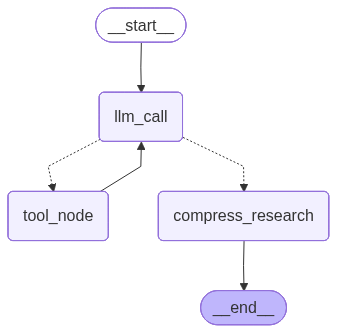

In [7]:
import base64
import httpx
from IPython.display import Image, display
from deep_research_from_scratch.research_agent import researcher_agent

# Show the agent
mermaid = researcher_agent.get_graph(xray=True).draw_mermaid()
encoded = base64.urlsafe_b64encode(mermaid.encode("utf-8")).decode("ascii")
image_url = f"https://mermaid.ink/img/{encoded}?type=png&bgColor=%21white"

with httpx.Client(timeout=20.0, verify=False, trust_env=True) as client:
    response = client.get(image_url)
    response.raise_for_status()
    png_bytes = response.content

display(Image(png_bytes))

In [8]:
# Run the agent
import uuid

from utils import format_messages, init_langfuse_tracing
from langchain_core.messages import HumanMessage

langfuse_handler = init_langfuse_tracing()

# Example brief
research_brief = """请研究近半年来（以今天 Fri Apr 24, 2026 为基准，约过去 6                                                           
个月）中国市场高端面部精华与面霜中“内容物本身”的液体/膏体设计元素趋势，明确排除外包装、瓶器、盒身、标签、泵头等包装
设计因素。我希望重点分析产品内容物在视觉与感官层面的趋势，包括：颜色（如透明、半透明、乳白、珠光、金属感、渐变感等 
）、装饰（如金箔/银箔、胶囊珠、悬浮颗粒、微气泡、花瓣/植物碎片、闪片等可见添加物或视觉点缀）、纹理感（如水感、凝胶 
感、丝绒感、奶霜感、啫喱感、拉丝感、厚薄度、流动性、包裹感等）。请优先使用中文来源，并尽量链接到品牌官方页面、品牌 
官方社媒/视频号/小红书/天猫旗舰店/京东旗舰店、权威美妆零售平台、行业媒体或可直接看到产品内容物实拍/演示的原始来源，
而不是二手汇总博客。请在研究中附上可参考图片或可直接查看图片/视频的原始链接，图片应尽量展示内容物本身而非包装。    

请按以下维度拆解趋势研究：                                                                                         

 1 [Geographic Market]                                                                                             
   在中国市场，近半年来高端面部精华/面霜内容物设计出现了哪些主流与新兴趋势？请限定在中国消费者可购买、且在中国市场 
   有传播与上新动作的高端品牌/产品，必要时区分国际品牌在中国与本土高端品牌的表现差异。                             
 2 [Product Category + Product Format]                                                                             
   面部精华与面霜这两个子品类中，内容物设计元素分别呈现出哪些不同趋势？请区分精华、乳霜，以及必要时纳入相关近邻质地
   （如精华凝胶、乳液霜、睡眠面膜式面霜）作为开放考虑，但不要偏离“面部精华/面霜”主范围。                           
 3 [Aesthetic Direction + Sensory Experience]                                                                      
   从颜色、装饰、纹理感三个核心维度出发，当前高端产品内容物的审美方向与感官体验趋势是什么？请总结高频视觉代码、触感
   联想、仪式感表达，以及这些设计如何服务于“高端感”“功效感”或“愉悦感”的传达。                                      
 4 [Claims and Evidence + Ingredient Strategy]                                                                     
   这些内容物设计元素通常如何与功效诉求、成分故事或科技话术绑定？请分析例如修护、抗老、焕亮、舒缓、屏障、奢养等常见
   高端护肤诉求，如何通过颜色、可见颗粒、珠光、胶囊化、悬浮体系、特殊纹理等被视觉化表达；若某些设计更多是审美/营销 
   导向而非功效必要，也请明确指出。                                                                                
 5 [Channel and Touchpoint + Trend Momentum]                                                                       
   哪些渠道最能观察到这些趋势的形成与扩散（如品牌官方图、上脸演示视频、达人测评、小红书、抖音、天猫详情页、专柜展示
   等）？请判断各类内容物设计趋势在近半年来是“新兴信号、加速增长、已趋主流还是热度回落”，并尽量给出可支持判断的上新
   案例、传播热度或重复出现信号。                                                                                  
 6 [Business Impact + Value Positioning]                                                                           
   从高端定位角度看，这些内容物设计趋势对品牌的商业与产品策略意味着什么？请分析哪些液体/膏体设计元素更常见于高端价 
   位带，哪些可能成为同质化风险，哪些可能构成未来的差异化机会。若价格带边界未被用户明确定义，请将“高端”作为中国护肤
   市场中的 premium/luxury 语境处理，并在研究中说明所采用的判断标准。                                              

输出时请尽量给出：代表性趋势清单、每个趋势对应的具体品牌/产品案例、可查看内容物的图片或视频链接、以及简要说明该案例
为何能代表该趋势。若某些图片仅能通过电商详情页、官方社媒帖子或视频截图观察，请明确标注来源与可见内容物的程度。
"""

thread_id = str(uuid.uuid4())
trace_tag = f"nb2-research-{thread_id[:8]}"
thread = {"configurable": {"thread_id": thread_id, "recursion_limit": "50", 
                           "scope_model":         "azure_openai:GPT-54-2026-03-05",
                            "research_model":      "azure_openai:GPT-54-2026-03-05",
                            "summarization_model": "azure_openai:GPT-54-2026-03-05",
                            "compress_model":      "azure_openai:GPT-54-2026-03-05",
                            "supervisor_model":    "azure_openai:GPT-54-2026-03-05",
                            "writer_model":        "azure_openai:GPT-54-2026-03-05",
         },
         "callbacks": [langfuse_handler],
         "tags": [trace_tag],
         "metadata": {
             "thread_id": thread_id,
             "notebook": "2_research_agent",
             "langfuse_session_id": thread_id,
             "langfuse_tags": [trace_tag],
         },
}
result = researcher_agent.invoke(
    {
        "researcher_messages": [HumanMessage(content=f"{research_brief}.")],
        "tool_call_iterations": 0,
        "research_topic": research_brief,
        "compressed_research": "",
        "raw_notes": [],
        "images": [],
    },
    config=thread
)
format_messages(result['researcher_messages'])

Failed to summarize webpage: Error code: 422 - {'detail': [{'type': 'enum', 'loc': ['path', 'deployment_id'], 'msg': "Input should be 'GPT-5-2025-08-07', 'GPT-5-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-MINI-2025-08-07', 'GPT-5-MINI-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-MINI-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-NANO-2025-08-07', 'GPT-5-NANO-2025-08-07-LOW-CONTENT-FILTERS', 'GPT-5-NANO-2025-08-07-NO-CONTENT-FILTERS', 'GPT-5-CHAT-2025-08-07', 'GPT-51-2025-11-13', 'GPT-51-2025-11-13-LOW-CONTENT-FILTERS', 'GPT-51-2025-11-13-NO-CONTENT-FILTERS', 'GPT-52-2025-12-11', 'GPT-52-2025-12-11-LOW-CONTENT-FILTERS', 'GPT-52-2025-12-11-NO-CONTENT-FILTERS', 'GPT-53-CHAT-2026-03-03', 'GPT-53-CHAT-2026-03-03-LOW-CONTENT-FILTERS', 'GPT-53-CHAT-2026-03-03-NO-CONTENT-FILTERS', 'GPT-54-2026-03-05', 'GPT-54-2026-03-05-LOW-CONTENT-FILTERS', 'GPT-54-2026-03-05-NO-CONTENT-FILTERS', 'GPT-54-PRO-2026-03-05', 'GPT-54-PRO-2026-03-05-LOW-CONTENT-FILTERS', 'GPT-54-PRO-2026-03-0

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 请研究近半年来（以今天 Fri Apr 24, 2026 为基准，约过去 6                                                        │
│ 个月）中国市场高端面部精华与面霜中“内容物本身”的液体/膏体设计元素趋势，明确排除外包装、瓶器、盒身、标签、泵头等 │
│ 包装                                                                                                            │
│ 设计因素。我希望重点分析产品内容物在视觉与感官层面的趋势，包括：颜色（如透明、半透明、乳白、珠光、金属感、渐变  │
│ 感等                                                                                                            │
│ ）、装饰（如金箔/银箔、胶囊珠、悬浮颗粒、微气泡、花瓣/植物碎片、闪片等可见添加物或视觉点缀）、纹理感（如水感、  │
│ 凝胶                                                                                                            │
│ 感、丝绒感、奶霜感、啫喱感、拉丝感、厚薄度、流动性、包裹感等）。请优先使用中文来源，并尽量链接到品牌官方页面、  │
│ 品牌                                                                                                            │
│ 官方社媒/视频号/小红书/天猫旗舰店/京东旗舰店、权威美妆零售平台、行业媒体或可直接看到产品内容物实拍/演示的原始来 │
│ 源，                                                                                                            │
│ 而不是二手汇总博客。请在研究中附上可参考图片或可直接查看图片/视频的原始链接，图片应尽量展示内容物本身而非包装。 │
│                                                                                                                 │
│ 请按以下维度拆解趋势研究：                                                                                      │
│                                                                                                                 │
│  1 [Geographic Market]                                                                                          │
│    在中国市场，近半年来高端面部精华/面霜内容物设计出现了哪些主流与新兴趋势？请限定在中国消费者可购买、且在中国  │
│ 市场                                                                                                            │
│    有传播与上新动作的高端品牌/产品，必要时区分国际品牌在中国与本土高端品牌的表现差异。                          │
│  2 [Product Category + Product Format]                                                                          │
│    面部精华与面霜这两个子品类中，内容物设计元素分别呈现出哪些不同趋势？请区分精华、乳霜，以及必要时纳入相关近邻 │
│ 质地                                                                                                            │
│    （如精华凝胶、乳液霜、睡眠面膜式面霜）作为开放考虑，但不要偏离“面部精华/面霜”主范围。                        │
│  3 [Aesthetic Direction + Sensory Experience]                                                                   │
│    从颜色、装饰、纹理感三个核心维度出发，当前高端产品内容物的审美方向与感官体验趋势是什么？请总结高频视觉代码、 │
│ 触感                                                                                                            │
│    联想、仪式感表达，以及这些设计如何服务于“高端感”“功效感”或“愉悦感”的传达。                                   │
│  4 [Claims and Evidence + Ingredient Strategy]                                                                  │
│    这些内容物设计元素通常如何与功效诉求、成分故事或科技话术绑定？请分析例如修护、抗老、焕亮、舒缓、屏障、奢养等 │
│ 常见                                                                                                            │
│    高端护肤诉求，如何通过颜色、可见颗粒、珠光、胶囊化、悬浮体系、特殊纹理等被视觉化表达；若某些设计更多是审美/  │
│ 营销                                                                                                            │
│    导向而非功效必要，也请明确指出。                                                                             │
│  5 [Channel and Touchpoint + Trend Momentum]                                                                    │
│    哪些渠道最能观察到这些趋势的形成与扩散（如品牌官方图、上脸演示视频、达人测评、小红书、抖音、天猫详情页、专柜 │
│ 展示                                                                                                            │
│    等）？请判断各类内容物设计趋势在近半年来是“新兴信号、加速增长、已趋主流还是热度回落”，并尽量给出可支持判断的 │
│ 上新                                                                                                            │
│    案例、传播热度或重复出现信号。                                                                               │
│  6 [Business Impact + Value Positioning]                                                                        │
│    从高端定位角度看，这些内容物设计趋势对品牌的商业与产品策略意味着什么？请分析哪些液体/膏体设计元素更常见于高  │
│ 端价                                                                                 

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "\u4e2d\u56fd \u9ad8\u7aef \u9762\u90e8\u7cbe\u534e \u9762\u971c \u5185\u5bb9\u7269 \u8d28\u5730     │
│ \u989c\u8272 \u9897\u7c92 \u5c0f\u7ea2\u4e66 \u5929\u732b \u5b98\u65b9 2025 11\u6708 2026 4\u6708"              │
│ }                                                                                                               │
│    ID: call_8MABgmdidRufnY2QOQw35vQp                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 日谈公园— podcast episodes - Podnews ---                                                          │
│ URL: https://podnews.net/podcast/ia7hu/episodes                                                                 │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ # 日谈公园 podcast episode list                                                                                 │
│ ![Image                                                                                                         │
│ 1](https://c.podnews.network/wow?0.05645653743620638&u=https%3A%2F%2Fpodnews.net%2Fpodcast%2Fia7hu%2Fepisodes&t │
│ ype=pageview&ref=)                                                                                              │
│                                                                                                                 │
│ -                                                                                                               │
│                                                                                                                 │
│ *   [News](https://podnews.net/archive)                                                                         │
│ *   [Jobs](https://podnews.net/jobs)                                                                            │
│ *   [Events](https://podnews.net/events)                                                                        │
│ *   [Articles](https://podnews.net/articles)                                                                    │
│ *   [Directory](https://podnews.net/directory)                                                                  │
│ *   [Press Releases](https://podnews.net/press-releases)                                                        │
│ *   [Advertise](https://podnews.net/article/advertising)                                                        │
│ *   [About](https://podnews.net/about)                                                                          │
│ *   [Privacy](https://podnews.net/privacy)                                                                      │
│ *   [Accessibility](https://podnews.net/accessibility)                                                          │
│ *   [Contact Podnews](https://podnews.net/contact-us)                                                           │
│                                                                                                                 │
│ [](https://podnews.net/)[](https://podnews.net/)                                                                │
│                                                                                                                 │
│ Search [](https://podnews.net/search)                                                                           │
│                                                                                                                 │
│ *   [News](https://podnews.net/archive)                                                                         │
│ *   [Jobs](https://podnews.net/jobs)                                                                            │
│ *   [Events](https://podnews.net/events)                       

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection":                                                                                                 │
│ "\u9996\u6b21\u5bbd\u6cdb\u641c\u7d22\u7ed3\u679c\u8d28\u91cf\u8f83\u5dee\uff0c\u51e0\u4e4e\u6ca1\u6709\u76f4\u │
│ 63a5\u547d\u4e2d\u4e2d\u56fd\u9ad8\u7aef\u9762\u90e8\u7cbe\u534e/\u9762\u971c\u5185\u5bb9\u7269\u8bbe\u8ba1\u76 │
│ 84\u5b98\u65b9\u6216\u539f\u59cb\u6765\u6e90\u3002\u5f53\u524d\u4ec5\u770b\u5230\u4e00\u5f20\u53ef\u80fd\u6765\ │
│ u81ea\u7535\u5546\u8be6\u60c5\u9875\u7684\u963f\u91cc\u56fe\u7247\u7ebf\u7d22\uff0c\u4e0d\u8db3\u4ee5\u652f\u64 │
│ 91\u7814\u7a76\u3002\u9700\u8981\u6539\u7528\u66f4\u6709\u9488\u5bf9\u6027\u7684\u54c1\u724c/\u6e20\u9053/\u89c │
│ 6\u89c9\u5173\u952e\u8bcd\u7ec4\u5408\uff0c\u4f18\u5148\u641c\u7d22\u5929\u732b\u65d7\u8230\u5e97\u3001\u4eac\u │
│ 4e1c\u3001\u5c0f\u7ea2\u4e66\u3001\u5fae\u4fe1\u89c6\u9891\u53f7/\u516c\u4f17\u53f7\u3001\u54c1\u724c\u5b98\u7f │
│ 51\uff0c\u5e76\u9501\u5b9a\u8fd16\u4e2a\u6708\u5728\u4e2d\u56fd\u5e02\u573a\u6709\u4e0a\u65b0\u4f20\u64ad\u7684 │
│ \u9ad8\u7aef\u54c1\u724c\u4e0e\u5177\u4f53\u4ea7\u54c1\u3002\u4e0b\u4e00\u6b65\u5e94\u5e76\u884c\u641c\u7d22\u5 │
│ 1e0\u4e2a\u9ad8\u76f8\u5173\u65b9\u5411\uff1a1\uff09\u9ad8\u7aef\u9762\u971c/\u7cbe\u534e                       │
│ \u9897\u7c92/\u80f6\u56ca/\u91d1\u7b94/\u60ac\u6d6e\u7b49\u53ef\u89c1\u5185\u5bb9\u7269\uff1b2\uff09\u4e2d\u56f │
│ d\u9ad8\u7aef\u62a4\u80a4\u65b0\u54c1 2025\u4e0b\u534a\u5e74-2026\u4e0a\u534a\u5e74                             │
│ \u884c\u4e1a\u5a92\u4f53\uff1b3\uff09\u5929\u732b/\u4eac\u4e1c \u65d7\u8230\u5e97                               │
│ \u8d28\u5730\u56fe/\u5185\u5bb9\u7269\u5b9e\u62cd\u3002"                                                        │
│ }                                                                                                               │
│    ID: call_ZTer2y6an6LBPTnJustLvL7E                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 海蓝之谜精华面霜，有3款，你选对了吗？面霜、乳霜、凝霜 ---                                         │
│ URL: https://zhuanlan.zhihu.com/p/351065325                                                                     │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 海蓝之谜面霜有3种质地，经典面霜、乳霜和凝霜。 海蓝之谜经典精华面霜 ...                                          │
│ 融化面霜，再按压到脸上。功效上，海蓝之谜经典精华面霜除了保湿滋润                                                │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: 「别样」- 海蓝之谜面霜有5种?! 本文教你选购适合的 ---                                              │
│ URL:                                                                                                            │
│ https://baleen-cdn.bybieyang.com/static/curation/deal_180822_lamergwp/deal_180822_lamergwp.html?v84c9d506baf332 │
│ df4941a7ed55f81e84                                                                                              │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![](/static/curation/deal_180822_lamergwp/2792ea2a-12ee-433f-a4b0-9da4e8d4f5b3.png)                             │
│                                                                                                                 │
│ ![](http://bxl.ipinyou.com/static/curation/authors/xiaoji.png)                                                  │
│                                                                                                                 │
│ 小吉 推荐                                                                                                       │
│                                                                                                                 │
│ * ![](/static/curation/deal_180822_lamergwp/4bbb4f0f-faaa-444b-8157-1a1cfb79a17c.png)                           │
│ * ### 使用珍贵的原料                                                                                            │
│ * ![](/static/curation/deal_180822_lamergwp/d1d45172-f8c4-4968-90db-8c4da58c3237.png)                           │
│ * ### 品牌灵魂 Miracle Broth™                                                                                   │
│                                                                                                                 │
│   神奇活性精萃 - Miracle                                                                                        │
│ Broth™，由太平洋深海中萃取的巨藻，通过3个月的天然发酵过程萃炼出的修护秘方。并且其融入每一件海蓝之谜的商品当中。 │
│ * ![](/static/curation/deal_180822_lamergwp/92ed97b8-4d7e-457d-9568-31c9aea7f473.png)                           │
│ * ### 美国时代周刊唯一入选护肤品                                                                                │
│ * ![](/static/curati

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Christian Dior 花秘瑰萃玫瑰微凝珠精华 50ml | Cosmetics Now 中华 ---                               │
│ URL:                                                                                                            │
│ https://cn.cosmeticsnow.com/iteminfo/christian-dior-dior-prestige-la-micro-huile-de-rose-universal-regenerating │
│ -micro-nutritive-concentrate-50ml                                                                               │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![](//d3pllp7nz3wmw5.cloudfront.net/images/cosmeticsnow/mobile_menu.svg)                                        │
│ ![](//d3pllp7nz3wmw5.cloudfront.net/images/cosmeticsnow/search-icon.svg)                                        │
│ ![](includes/templates/cosmeticsnow/images/logo-cosmetics-updated.svg)                                          │
│                                                                                                                 │
│ ### 订单跟进                                                                                                    │
│                                                                                                                 │
│ ![](//d3pllp7nz3wmw5.cloudfront.net/images/cosmeticsnow/account.svg)                                            │
│ ![](//d3pllp7nz3wmw5.cloudfront.net/images/ajax-loader-small.gif)                                               │
│                                                                                                                 │
│ ##### [A](#)                                                                                                    │
│                                                                                                                 │
│ ##### [B](#)                                                                                                    │
│                                                                                                                 │
│ ##### [C](#)                                                                                                    │
│                                                                                                                 │
│ ##### [D](#)                                                                                                    │
│                                                                                                                 │
│ ##### [E](#)                                                                                                    │
│                                                                                                                 │
│ ##### [F](#)                                                                                                    │
│                                                                                                                 │
│ ##### [G](#)                                                                                                    │
│                                                                                                                 │
│ ##### [H](#)                                                            

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Instagram ---                                                                                     │
│ URL: https://www.instagram.com/reel/DUAsiaeiQT9/                                                                │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![](data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAKAAAACgCAYAAACLz2ctAAAtXklEQVR4AezBAQ0AAAjAoNu/tDl0QAAAAAAAA │
│ G9NRy179gDrX9NdcfyzZ8793b9r27Zt2wqqoHYb1rYdt1Hj1AhqI6jdPrafizO7uHOSnfMi+uvFTlZm73XO9TdrZnK/TB6/Ctef5jqudm4MbgTX │
│ BofGUXAYHJaLvq/GUee4GR2tGz2tndaa80a2hWhAdCPCiAA0dBmBBQ1bH4BONqFJi8ggm6FrGWRnXKwxmrHS1kWsYYyDOBucdLk27Sycnod2cix │
│ Ohzw7Fs8NnljFk8PZ01fFs087fRzPegmt+HP3uNvrF7325eD1lu6t1/SW2bxWX71x8iqRDskRjoNlqk9FoyW9yUjZQvYwgmxdIqMRzRoNNuiEjm │
│ YIIqQmNQQaltJvft/gFLnNDX3OIbLJ7FKIPBIjZAbTjzUYTeairawjGOToYm2chHG6cIa1y8eSe7r492Y8EM7/7Ez7rzf1mg8j3eUVKd1N9ZVXv │
│ UY786qteUfpnYKPkN5QuhaJokgCEEUNCbM34QlDQxhCCpu/gjb9xtTQUOHr6ucMCzbfXKN4Md+pMIbQ6rtzbnLO1Ln21QspdjPDBaT53138NeN3 │
│ mvO/Pji+7xW95n04eTmAu/o8Lr3qVW++nnmj1ny08B6R3ly6DJEYhLnu4bPv9zCOCVAW+NjgaxID6QghN1AnHEOvMBTgluLt4eo28KI+n37Od7M │
│ AOHQNSQGvzb4CGGWtgDLUPlg79zTrn5G/162//4z1P/Cwu6DiHv/gTtYPXXnzj8nwYdL7S6/b0qtFIIkJm6TC15JaHQqE6h+spF2Xcs6b39VkTI │
│ tkex/toi/gbT52oDW0CZitl5svsGy9nE5qWMQOMKImq6SAW1O5wvjCNbbPfTqs/975S/JXbzj/VTxyhxPw79yJ+porb/lOwee15qMNryNdikQWg │
│ C...                                                                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: 【赫蓮娜黑繃帶面霜  】抗老修護一次到位♥️   30%高濃度玻色因 ... ---                                 │
│ URL:                                                                                                            │
│ https://www.facebook.com/MixxCollectionHK/videos/%E8%B5%AB%E8%93%AE%E5%A8%9C%E9%BB%91%E7%B9%83%E5%B8%B6%E9%9D%A │
│ 2%E9%9C%9C%E6%8A%97%E8%80%81%E4%BF%AE%E8%AD%B7%E4%B8%80%E6%AC%A1%E5%88%B0%E4%BD%8D%EF%B8%8F30%E9%AB%98%E6%BF%83 │
│ %E5%BA%A6%E7%8E%BB%E8%89%B2%E5%9B%A0%E5%A5%87%E8%B9%9F%E5%8D%87%E7%B4%9A%E4%B8%80%E7%BD%90%E6%90%9E%E5%AE%9A%E6 │
│ %89%80%E6%9C%89%E8%82%8C%E8%86%9A%E7%85%A9%E6%83%B1%EF%B8%8F%EF%B8%8F%E9%87%8D%E7%A3%85%E6%8A%97%E8%80%81%E6%A5 │
│ %B5%E8%87%B4%E4%BF%AE%E8%AD%B7%EF%B8%8F30%E7%8E%BB%E8%89%B2%E5%9B%A0%E7%9B%B4%E9%81%94%E8%82%8C%E5%BA%95%EF%B8% │
│ 8F%E8%88%92%E7%B7%A9%E6%B3%9B%E7%B4%85%E5%BC%B7%E5%8C%96%E5%B1%8F%E9%9A%9C%E8%B3%AA%E5%9C%B0%E9%AB%94%E9%A9%97% │
│ E5%A4%AA%E9%A9%9A%E8%89%B7-%E6%8E%A8%E9%96%8B%E6%98%AF%E9%AB%98/1557057895297176/                               │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 零厚重！ ➤ 乳化後秒吸收～臉蛋瞬間「嘭起來」 膚質適配指南： ✓ 油肌姐妹直接衝～清爽啞光超友好！ ✓                 │
│ 乾肌像我～

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: 品类标准解读：护肤水的价值洼地，林清轩“小金珠”如何用“水油同补”破局？_中华网 ---                   │
│ URL: https://mtz.china.com/touzi/2026/0419/228305.html                                                          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ [首页](http://www.china.com/)*|* [新闻](http://news.china.com/)*|* [军事](http://military.china.com)*|*         │
│ [汽车](http://auto.china.com/)*|* [游戏](http://game.china.com/)*|* [科技](http://tech.china.com/)*|*           │
│ [旅游](http://travel.china.com/)*|* [经济](http://finance.china.com/)*|* [娱乐](http://ent.china.com/)*|*       │
│ [投资](http://money.china.com)*|* [文化](http://culture.china.com/)*|* [守艺中华](http://shouyi.china.com/)*|*  │
│ [佛教](http://fo.china.com/)*|* [红木](http://hongmu.china.com)*|* [城市](http://city.china.com/)*|*            │
│ [韩流](http://korea.china.com/)*|* [信息](http://xinxi.china.com/)*|* [简读](http://club.china.com/)            │
│                                                                                                                 │
│ [![中华网](https://tech.china.com/static_digi/images/pclogo_zhwtz.png)](http://www.china.com)                   │
│                                                                                                                 │
│ 当前位置 ： [投资](https://mtz.china.com/) > [资讯](https://mtz.china.com/touzi/)                               │
│                                                                                                                 │
│ # 品类标准解读：护肤水的价值洼地，林清轩“小金珠”如何用“水油同补”破局？                                          │
│                                                                                                                 │
│ [小](#) [大](#)                                                                                                 │
│                                                                                                                 │
│ 2026-04-19 20:59:31   来源：财讯网                                                                              │
│                                                                                                                 │
│ 护肤水，一个看似“入门级”的品类，却在无声中酝酿着一场价值重构。过去十年，从二次清洁到保湿打底，护肤水的角色定位  │
│ 一直模糊。当精华、面霜卷上天，护肤水仿佛成了最尴尬的存在——食之无味，弃之可惜。但事实果真如此吗？将目光投向产业  │
│ 端，会发现一些高段位玩家正试图用技术创新，重新激活这片“价值洼地”。林清轩全新上市的“小金珠”嘭弹...               │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: 所有女生！这瓶林清轩山茶花抗皱修护精华油，真的能让你的脸回到18岁！_液态精华_淘宝美妆网 ---        │
│ URL: https://beaut.taobao.com/topic/yetaijinghua_22/ab3dbc9b2033ff32b18a135768f93872                            │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ ![](//gw.alicdn.com/imgext

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 以下是基于**近半年（约 2025/10/24–2026/04/24）中国市场**可见公开信息做的趋势研究。                              │
│ 我严格**排除了外包装/瓶器/盒身/标签/泵头**，只讨论**内容物本身**的液体/膏体设计：颜色、可见装饰/颗粒、纹理与流  │
│ 动性、上脸触感与仪式感。                                                                                        │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # 研究说明与口径                                                                                                │
│                                                                                                                 │
│ ## 1) “高端”如何界定                                                                                            │
│ 本研究将“高端”按中国护肤市场的 **premium / luxury** 语境处理，优先纳入：                                        │
│ - 国际奢护/高端护肤品牌在中国市场销售并有传播动作的产品                                                         │
│ - 中国本土高端/高端化品牌中，单品定价、渠道与传播明显向高端靠拢者                                               │
│ - 典型价格带大致参考：                                                                                          │
│   - 精华：约 **800元+**，尤其 **1500元+** 奢护段                                                                │
│   - 面霜：约 **1000元+**，尤其 **2000元+** 奢护段                                                               │
│                                                                                                                 │
│ ## 2) 证据来源优先级                                                                                            │
│ 我优先参考了：                                                                                                  │
│ - 品牌官网/品牌中国官网                                                                                         │
│ - 时尚与行业媒体中的原始新品报道                                                                                │
│ - 可看到内容物本身的图/视频页面                                                                                 │
│ - 少量电商/零售页，仅用于补充质地实拍线索                                                                       │
│                                                                                                                 │
│ ## 3) 本次研究的现实限制                                                                                        │
│ 过去 6 个月里，很多品牌传播仍以“包装 hero shot”为主，**直接把内容物拍清楚**的官方页面并不总是充分。             │
│ 因此文中我会明确标注：                                                                                          │
│ - **A类：官方明确描述+可见内容物图**                                                                            │
│ - **B类：官方描述强，但图中内容物可见程度一般**                                                                 │
│ - **C类：媒体/零售页可见内容物实拍，作为辅助观察**                                                              │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ # 一、结论先行：近半年中国高端面部精华/面霜“内容物本身”5大趋势                                                  │
│                                                                                                                 │
│ ## 主流趋势 1：**“可见科技感”强化——微珠、微囊、悬浮粒成为高端精华最强视觉代码**                                 │
│ 过去半年最明显的方向，不是单纯“更华丽”，而是**让功效被看见**。                                                  │
│ 典型表现：                                                                                                      │
│ - 透明/半透明基底中出现**金色、琥珀色、粉色微珠**                                                            

In [9]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

  1 中国 高端 面部精华 面霜 内容物 质地 颜色 颗粒 小红书 天猫 官方 2025 11月 2026 4月                              
  2 site:tmall.com 高端 精华 颗粒 胶囊 天猫 旗舰店 面霜 珠 光 2026                                                 
  3 site:xiaohongshu.com 高端 面霜 精华 质地 颗粒 珠光 官方 2026 中国                                              
  4 2025 2026 中国 高端 护肤 新品 精华 面霜 质地 行业媒体 珠光 颗粒                                                
  5 2025 下半年 2026 上半年 中国 高端 护肤 新品 精华 面霜 行业媒体                                                 
  6 兰蔻 菁纯 面霜 质地 视频 官方 中国 2026                                                                        
  7 娇兰 帝皇蜂姿 精华 微珠 质地 官方 中国 2026                                                                    
  8 海蓝之谜 精华面霜 质地 官方 中国 面霜 乳霜 融化                                                                
  9 迪奥 花秘瑰萃 精华 面霜 质地 官方 中国 微粒 玫瑰                                                               
 10 赫莲娜 黑绷带 面霜 质地 官方 中国 绷带 乳霜                                                                    
 11 林清轩 高端 精华 面霜 质地 官方 中国 山茶花 油珠 2026                                                          

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fully Comprehensive Findings                                                                                       


                                                研究范围与判定口径                                                 

 • 研究主题限定为：中国市场近半年来（相对 2026-04-24 约过去 6                                                      
   个月）高端面部精华与面霜中“内容物本身”的液体/膏体设计元素趋势，明确排除外包装、瓶器、盒身、标签、泵头等包装设计 
   因素。                                                                                                          
 • 关注维度包括：颜色、装饰（如金箔/银箔、胶囊珠、悬浮颗粒、微气泡、花瓣/植物碎片、闪片等可见添加物或视觉点缀）、纹
   理感（如水感、凝胶感、丝绒感、奶霜感、啫喱感、拉丝感、厚薄度、流动性、包裹感等）。                              
 • “高端”按中国护肤市场中的 premium / luxury                                                                       
   语境处理，优先纳入国际奢护/高端护肤品牌在中国市场销售并有传播动作的产品，以及中国本土高端/高端化品牌中单品定价、
   渠道与传播明显向高端靠拢者。此前整理中给出的参考价格带为：精华约 800 元+，尤其 1500 元+ 奢护段；面霜约 1000     
   元+，尤其 2000 元+ 奢护段。                                                                                     


                                                宏观市场与趋势背景                                                 

 • 新华网转载《2025年度美妆护肤线上市场趋势洞察》指出：                                                            
   “2025年美妆护肤线上市场量价齐升，全年销售额达4541.8亿元，同比增长9.7%，销量51.3亿件，同比增长5.5%。市场呈现鲜明 
   的‘大众盘稳固、高端线高增’双向格局，100元以下价位段以20.6%的增速领跑大盘，1000元以上高端线亦增长亮眼，消费分层加
   速、升级与分级并行。”[1]                                                                                        
   同文还指出：                                                                                                    
   “消费者正在用更理性的方式重新分配手中的预算：一边精打细算，一边又愿意为看得见的效果买单。”[1]                   
 • 护肤趋势上，新华网该文指出：                                                                                    
   “抗衰抗皱已从‘被动防护’转向‘主动预防’，需求突破年龄与性别边界，20+年轻群体抗初老需求快速崛起，推动功效护肤成为核
   心增长引擎。”[1]                                                                                                
 • Jing Daily 关于 2025 中国美妆趋势总结称：                                                                       
   “2025                                                                                                           
   年，中国美妆行业正在经历一次深层次的价值重估。流量、噱头与概念红利逐渐退潮，消费者开始用更接近科研、医疗和生活方
   式的标准，审视每一款产品与每一个品牌。”[2]                                                                      
   该文还写道：                                                                                                    
   “行业竞争的核心正从营销效率，转向功效实证与信任构建。”[2]                                                       
   并指出：                                                                                                        
   “2025 年的行业赢家未必是声量最大的品牌，但一定是定位最精准的。”[2]                                              
 • 基于以上宏观背景，研究过程中形成的判断是：高端面部精华/面霜的内容物设计，不再只是“

## Eval

Agents use a self-directed trajectory of tool calls to accomplish tasks.

Let's think about the ramifications of a poorly tuned tool-calling loop: 

- Early Termination: The agent decides to stop calling tools when the task is not actually complete. 
- Prolonged Looping: The agent is never satisfied with the state of its information. 

The first failure  mode results in the agent collecting insufficient information. In the deep research context, the answer may end up being too shallow. The second failure mode results in the agent utilizing an excessive number of tokens. In the deep research context, irrelevant information may poison the result.

We tuned our prompt to avoid these problems. But, let's se up a toy eval dataset that allows us to easily test agent decision-making.

In [4]:
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

# Scenario 1: Agent should CONTINUE - has insufficient/irrelevant information + think_tool realizes more research needed
messages_should_continue = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll search for information about top coffee shops in San Francisco focusing on coffee quality.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "coffee shops San Francisco popular locations"
                },
                "id": "call_continue_search_001",
                "type": "tool_call"
            }
        ]
    ),
    # Tavily Search provides generic cafe information - NOT focused on coffee quality
    ToolMessage(
        content="Search results show popular San Francisco cafes: Blue Bottle Coffee has great wifi and ambiance, Philz Coffee is known for custom blends and friendly service, Café Reveille has multiple locations with good pastries and laptop-friendly spaces. Ritual Coffee offers cozy seating and is popular with students.",
        tool_call_id="call_continue_search_001",
    ),
    # Agent uses think_tool to reflect and realizes the search results are insufficient
    AIMessage(
        content="Let me use the think_tool to analyze these search results and determine next steps.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality."
                },
                "id": "call_continue_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response identifies the gap and need for more targeted research
    ToolMessage(
        content="Reflection recorded: Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality.",
        tool_call_id="call_continue_think_001",
    )
]

# Scenario 2: Agent should STOP - has comprehensive coffee quality information + think_tool reflection
messages_should_stop = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll research San Francisco coffee shops specifically focusing on coffee quality assessments and expert reviews.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "best coffee quality San Francisco specialty coffee expert reviews Coffee Review ratings 2024"
                },
                "id": "call_stop_search_001", 
                "type": "tool_call"
            }
        ]
    ),
    # This ToolMessage provides COMPREHENSIVE coffee quality information - sufficient to answer the question
    ToolMessage(
        content="""Coffee quality research for San Francisco reveals top establishments based on expert reviews and specialty coffee credentials:

**Top Quality-Focused Coffee Shops:**
1. **Sightglass Coffee** - Coffee Review score 94/100, known for single-origin beans and precise roasting techniques. Featured in Bon Appétit's "Best Coffee in America" list for exceptional coffee quality.

2. **Saint Frank Coffee** - Ranked #3 coffee shop in America by The Daily Meal based on coffee quality. 4.3/5 Yelp rating with reviews specifically praising "exceptional bean quality" and "perfect extraction."

3. **Ritual Coffee Roasters** - Specialty Coffee Association member, direct trade relationships, consistently rated 4.4/5 on Google with reviews highlighting "superior coffee taste" and "expert barista skills."

4. **Blue Bottle Coffee** - Third-wave coffee pioneer, Coffee Review scores averaging 90+/100, known for rigorous quality control and fresh roasting practices.

5. **Four Barrel Coffee** - Local roaster with Coffee Review scores 88-92/100, praised by industry experts for "exceptional coffee quality" and innovative brewing methods.

**Quality Indicators Found:**
- Coffee Review professional scores (88-94/100 range)
- Specialty Coffee Association certifications
- Direct trade/single-origin sourcing
- Expert recognition from food publications
- Customer reviews specifically mentioning coffee taste and quality

This provides a comprehensive assessment of SF coffee shops based specifically on coffee quality rather than ambiance or service.""",
        tool_call_id="call_stop_search_001",
    ),
    # Agent now uses think_tool to reflect on the search results
    AIMessage(
        content="Let me reflect on the search results using the think_tool to assess whether I have sufficient information.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now."
                },
                "id": "call_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response confirming reflection was recorded
    ToolMessage(
        content="Reflection recorded: Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now.",
        tool_call_id="call_think_001",
    )
]

We'll create a dataset here that has one example that should continue researching, and another example that should have all of the information necessary.

In [5]:
from utils import init_langfuse

langfuse = init_langfuse()

# Create the dataset and populate items (idempotent)
dataset_name = "deep_research_agent_termination"
try:
    ds = langfuse.get_dataset(dataset_name)
    print(f'Dataset "{dataset_name}" already exists ({len(ds.items)} items).')
except Exception:
    ds = None

if ds is None or len(ds.items) == 0:
    if ds is None:
        langfuse.create_dataset(
            name=dataset_name,
            description="A dataset that evaluates whether a researcher can accurately decide to continue calling tools, or to stop.",
        )
    for item in [
        {
            "input": {"researcher_messages": messages_should_continue},
            "expected_output": {"next_step": "continue"},
        },
        {
            "input": {"researcher_messages": messages_should_stop},
            "expected_output": {"next_step": "stop"},
        },
    ]:
        langfuse.create_dataset_item(
            dataset_name=dataset_name,
            input=item["input"],
            expected_output=item["expected_output"],
        )
    langfuse.flush()
    print(f'Created/populated dataset "{dataset_name}" with 2 items.')


Dataset "deep_research_agent_termination" already exists (2 items).


Here, our evaluator is simple, using a hard-coded heuristic to check if the agent correctly continues or stops.

We'll pass in the list of messages above.

We'll assess the decision made by the agent: 

* `stop` - No tool calls means the agent should stop
* `continue` - Tool calls means the agent should continue

We'll then compare this decision to the reference expected decision `next_step`.

In [7]:
import uuid
from typing import cast
from langchain_core.messages import convert_to_messages
from langchain_core.runnables import RunnableConfig
from langfuse import Evaluation
from deep_research_from_scratch.state_research import ResearcherState


def evaluate_next_step(*, input, output, expected_output, metadata=None, **kwargs):
    """Heuristic evaluator: check if the agent correctly continues or stops."""
    del input, metadata, kwargs
    tool_calls = output["researcher_messages"][-1].tool_calls
    made_tool_call = len(tool_calls) > 0
    is_correct = made_tool_call == (expected_output["next_step"] == "continue")
    return Evaluation(
        name="correct_next_step",
        value=1.0 if is_correct else 0.0,
        comment=f"expected={expected_output['next_step']}, tool_calls={len(tool_calls)}",
    )


def target_func(*, item, **kwargs):
    """Run a single LLM call node for evaluation."""
    del kwargs
    # Langfuse stores messages as serialized dicts; convert back to LangChain objects
    raw_msgs = item.input["researcher_messages"]
    messages = (
        convert_to_messages(raw_msgs)
        if raw_msgs and isinstance(raw_msgs[0], dict)
        else raw_msgs
    )
    config: RunnableConfig = {"configurable": {"thread_id": str(uuid.uuid4())}}
    state = cast(
        ResearcherState,
        {
            "researcher_messages": messages,
            "tool_call_iterations": 0,
            "research_topic": "",
            "compressed_research": "",
            "raw_notes": [],
            "images": [],
        },
    )
    return researcher_agent.nodes["llm_call"].invoke(
        state,
        config=config,
    )


experiment = langfuse.run_experiment(
    name=dataset_name,
    run_name="Researcher Iteration",
    data=langfuse.get_dataset(dataset_name).items,
    task=target_func,
    evaluators=[evaluate_next_step],
)
print(experiment.format())
print(f"Experiment complete: {len(experiment.item_results)} items evaluated")

Individual Results: Hidden (2 items)
💡 Set include_item_results=True to view them

──────────────────────────────────────────────────
🧪 Experiment: deep_research_agent_termination
📋 Run name: Researcher Iteration
2 items
Evaluations:
  • correct_next_step

Average Scores:
  • correct_next_step: 1.000

🔗 Dataset Run:
   http://localhost:3000/project/cmob9be7m0007n0077l72py9z/datasets/cmoba895u000mn007agm6gb41/runs/125c8c78-fb89-4b44-97de-50d20f912182
Experiment complete: 2 items evaluated
